In [1]:
import logging
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import flox.xarray

from graphufs.stacked_utils import get_channel_index
from prototypes.ocn_only.emulator import OcnTrainer

In [2]:
def cross_covariance_xr(
    da: xr.DataArray,
    dim: str = "channels",
    spatial_avg: bool = True,
    lat_dim: str = "lat",
    lon_dim: str = "lon",
    norm: bool = False
) -> xr.DataArray:
    """
    Calculates the cross-covariance or correlation matrix for all pairs
    along a given dimension.

    This function is robust, using xarray's label-based assignment
    to prevent dimension misalignment.

    Args:
        da (xr.DataArray): The input DataArray. Must have a "sample" dimension
                           and the specified `dim`.
        dim (str): The shared dimension along which variables are defined.
        spatial_avg (bool): If True, spatially average the covariance.
        lat_dim (str): Name of the latitude dimension.
        lon_dim (str): Name of the longitude dimension.
        norm (bool): If True, compute correlation instead of covariance.

    Returns:
        xr.DataArray: A DataArray containing the cov/corr matrix.
    """

    # Get coordinate values from the dimension
    channel_coords = da[dim]

    # Define the output dimensions and coordinates for our empty array
    out_dims = [f"{dim}_x", f"{dim}_y"]
    out_coords = {f"{dim}_x": channel_coords.values, f"{dim}_y": channel_coords.values}

    # Define the shape of the empty data
    out_shape = (len(channel_coords), len(channel_coords))

    if not spatial_avg:
        # Add spatial dimensions and coordinates if not averaging
        out_dims.extend([lat_dim, lon_dim])
        out_coords[lat_dim] = da[lat_dim]
        out_coords[lon_dim] = da[lon_dim]
        out_shape += (da.sizes[lat_dim], da.sizes[lon_dim])

    # Create the empty 'shell' DataArray, filled with NaNs
    # This is the robust way to pre-allocate.
    out_da = xr.DataArray(
        data=np.full(out_shape, np.nan),
        dims=out_dims,
        coords=out_coords
    )

    # Select the correct operation (cov or corr)
    op = xr.corr if norm else xr.cov
    statistic = "correlation" if norm else "covariance"

    # Iterate over channel values
    for i in range(len(channel_coords)):
        print(f"i = {i}")
        # Only compute the upper triangle (j >= i)
        for j in range(i, len(channel_coords)):
            print(f"j = {j}")

            channel_i_val = channel_coords[i].item()
            channel_j_val = channel_coords[j].item()

            # Select the data for each channel using .sel()
            da_i = da.sel({dim: channel_i_val})
            da_j = da.sel({dim: channel_j_val})

            # Calculate covariance/correlation
            # This result will have 'lat' and 'lon' dims
            out_cov = op(da_i, da_j, dim="sample")

            # Create the dictionary for .loc to select the correct "slot"
            loc_ij = {f"{dim}_x": channel_i_val, f"{dim}_y": channel_j_val}
            loc_ji = {f"{dim}_x": channel_j_val, f"{dim}_y": channel_i_val}

            if spatial_avg:
                out_mean = out_cov.mean([lat_dim, lon_dim], skipna=True)
                out_da.loc[loc_ij] = out_mean
                out_da.loc[loc_ji] = out_mean.copy() # Apply symmetry
            else:
                # Let xarray handle the assignment of the full spatial field
                out_da.loc[loc_ij] = out_cov
                out_da.loc[loc_ji] = out_cov.copy() # Apply symmetry

    # 6. Add attributes and return
    out_da.attrs["description"] = f"Cross-{statistic} over 'sample' dim."
    return out_da

In [3]:
def cross_covariance_looped(da: xr.DataArray, dim: str = "channels", norm = False):
  """
  Calculates the cross-covariance matrix for all pairs along dim.

  Args:
    da (xr.DataArray): The input DataArray.
    dim (str): The shared dimension along which variables are defined.
    norm (bool): If true, normalization by std will be applied to compute correlation

  Returns:
    xr.DataArray: A DataArray containing the cov/corr matrix.
  """

  channels = da[dim]  # Get the dim values 
  out_mat = np.zeros((len(channels), len(channels)))
  
  for i in range(len(channels)):
    print("i = ", i)
    for j in range(i, len(channels)):
      print("j = ", j)
      channel_i = channels[i]
      channel_j = channels[j]

      # Calculate covariance
      if not norm:
          out_mat[i, j] = xr.cov(da.isel({dim:channel_i}), 
                                 da.isel({dim:channel_j}),
                                 dim = "sample").mean(["lat","lon"], skipna=True)
          statistic = "covariance"
      else:
          out_mat[i, j] = xr.corr(da.isel({dim:channel_i}), 
                                  da.isel({dim:channel_j}),
                                  dim = "sample").mean(["lat","lon"], skipna=True)
          statistic = "correlation"

      # apply symmetry
      out_mat[j, i] = out_mat[i, j].copy()

  # convert to dataArray
  out_da = xr.DataArray(out_mat, 
                        dims=["channels_x","channels_y"], 
                        coords={"channels_x":channels.values, "channels_y":channels.values}, 
                        attrs={"description":f"tendency {statistic}"})
  return out_da

In [2]:
def cross_covariance(da: xr.DataArray,
                     dim: str = "channels",
                     spatial_avg: bool = True,
                     lat_dim: str = "lat",
                     lon_dim: str = "lon",
                     norm: bool = False) -> xr.DataArray:
    """
    Calculates the cross-covariance or cross-correlation matrix for all pairs 
    along dim.

    Args:
        da (xr.DataArray): The input DataArray, which should be loaded into memory.
                           ('sample', 'lat', 'lon', 'channels').
        dim (str): The dimension along which variables are defined (e.g., "channels").
        spatial_avg (bool): If True, spatially average the covariance/correlation.
        lat_dim (str): Name of the latitude dimension.
        lon_dim (str): Name of the longitude dimension.
        norm (bool): If true, compute correlation instead of covariance.

    Returns:
        xr.DataArray: A DataArray containing the full covariance or correlation matrix.
    """

    n_samples = da.sizes["sample"]

    if not norm:
        statistic = "covariance"
        # For covariance, the one-pass demean -> dot product is stable and correct.
        da_demeaned = da - da.mean(dim="sample", skipna=True)
        da1 = da_demeaned.rename({dim: f"{dim}_x"})
        da2 = da_demeaned.rename({dim: f"{dim}_y"})
        cov_map = xr.dot(da1, da2, dims="sample") / (n_samples - 1)
        out_matrix = cov_map #.mean(["lat", "lon"], skipna=True)

    else:
        statistic = "correlation"
        # First z-score the data and then compute the covariance of the result.

        # Calculate mean and sample standard deviation (with ddof=1).
        mean = da.mean(dim="sample", skipna=True).persist()
        std = da.std(dim="sample", skipna=True, ddof=1).persist()
        #epsilon = 1e-12 # when turned on, this is leading inconsistencies,
                         # menifested by the diag entries of corr not eq 1. 

        # Z-score the data.
        da_zscored = (da - mean) / std

        # The correlation is the covariance of the z-scored data.
        da1 = da_zscored.rename({dim: f"{dim}_x"})
        da2 = da_zscored.rename({dim: f"{dim}_y"})

        # The dot product of z-scored data, divided by (n-1), is the correlation map.
        corr_map = xr.dot(da1, da2, dims="sample") / (n_samples - 1)

        # 4. Average the correlation map over spatial dimensions.
        out_matrix = corr_map #.mean(["lat", "lon"], skipna=True)

    if spatial_avg:
        out_matrix = out_matrix.mean([lat_dim, lon_dim], skipna=True)

    out_matrix.attrs = {"description": f"tendency {statistic}"}

    return out_matrix

In [3]:
def search_meta_dict(data:dict, var_key:str, var_val:str, 
                    vcoord_key:str = None, vcoord_val:int = None):
    result = None
    for idx, inner_dict in data.items():
        if var_key in inner_dict and inner_dict[var_key] == var_val:
            if vcoord_key is not None:
                if vcoord_key in inner_dict and inner_dict[vcoord_key] == vcoord_val:
                    result = idx
                    break
            else:
                result = idx
                break
                
    if result is not None:
        return result
    else:
        error_str = f"{var_key}:{var_val}"
        if vcoord_key is not None:
            error_str += f", {vcoord_key}:{vcoord_val} combination"
        raise KeyError(f"{error_str} does not exist")
        return 

In [4]:
def plot_correlation(ax, da: xr.DataArray, 
                     meta: dict = None,
                     ticks: tuple = (0, 1, 8, 15, 22),
                     title: str = None,
                     vmin: float = None, 
                     vmax: float = None,
                    ):
    da.plot(ax=ax, cmap="RdBu_r", vmin=vmin, vmax=vmax)
    ax.set_xticks(ticks,); ax.set_yticks(ticks,)
    if meta is not None:
        ticklabels = [meta[i]["varname"] for i in ticks]   
        ax.set_xticklabels(ticklabels,)
        ax.set_yticklabels(ticklabels,)
        ax.tick_params(labelrotation=45)
    if title is not None:
        ax.set_title(title)
    return  

In [5]:
# Meta Data
_scratch = "/pscratch/sd/n/nagarwal/"
_prototype = "ocn-only"
_expt = "R5" 
_sub_expt = "T1M"
_prototype_home = "/global/homes/n/nagarwal/graph-ufs/prototypes/"
_training_dir = os.path.join(_scratch, _prototype, _expt, "training")

target_lead_time = 24 # in hours
delta_t_data = 6 # in hours
num_missing_samples = 0 if target_lead_time == 6 else 3  # 0 for 6h and 3 for 24h
remove_seasonality = False
training_dates = ["1993-12-31T18", "2019-12-31T18"]

In [6]:
# Open Targets 
fname = "targets.zarr"
ds = xr.open_zarr(os.path.join(_training_dir, fname))
ds

<xarray.Dataset> Size: 650GB
Dimensions:   (channels: 29, lat: 192, lon: 384, sample: 37978)
Coordinates:
  * channels  (channels) int64 232B 0 1 2 3 4 5 6 7 ... 21 22 23 24 25 26 27 28
  * lat       (lat) float64 2kB 89.82 88.89 87.95 87.01 ... -87.25 -88.18 -89.12
  * lon       (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
  * sample    (sample) int64 304kB 0 1 2 3 4 5 ... 37973 37974 37975 37976 37977
Data variables:
    targets   (sample, lat, lon, channels) float64 650GB dask.array<chunksize=(1, 192, 384, 29), meta=np.ndarray>

In [7]:
# Channel Meta Data
_inference_dir = os.path.join(_scratch, _prototype, _expt,
                              f"inference_{_sub_expt}", "validation")
fname = "graphufs.240h.zarr"
ds_pred = xr.open_zarr(os.path.join(_inference_dir, fname))
meta_targets = get_channel_index(ds_pred, preserved_dims=("time","lead_time","lat","lon"))
meta_targets

{0: {'varname': 'SSH'},
 1: {'varname': 'so', 'z_l': 0},
 2: {'varname': 'so', 'z_l': 1},
 3: {'varname': 'so', 'z_l': 2},
 4: {'varname': 'so', 'z_l': 3},
 5: {'varname': 'so', 'z_l': 4},
 6: {'varname': 'so', 'z_l': 5},
 7: {'varname': 'so', 'z_l': 6},
 8: {'varname': 'temp', 'z_l': 0},
 9: {'varname': 'temp', 'z_l': 1},
 10: {'varname': 'temp', 'z_l': 2},
 11: {'varname': 'temp', 'z_l': 3},
 12: {'varname': 'temp', 'z_l': 4},
 13: {'varname': 'temp', 'z_l': 5},
 14: {'varname': 'temp', 'z_l': 6},
 15: {'varname': 'uo', 'z_l': 0},
 16: {'varname': 'uo', 'z_l': 1},
 17: {'varname': 'uo', 'z_l': 2},
 18: {'varname': 'uo', 'z_l': 3},
 19: {'varname': 'uo', 'z_l': 4},
 20: {'varname': 'uo', 'z_l': 5},
 21: {'varname': 'uo', 'z_l': 6},
 22: {'varname': 'vo', 'z_l': 0},
 23: {'varname': 'vo', 'z_l': 1},
 24: {'varname': 'vo', 'z_l': 2},
 25: {'varname': 'vo', 'z_l': 3},
 26: {'varname': 'vo', 'z_l': 4},
 27: {'varname': 'vo', 'z_l': 5},
 28: {'varname': 'vo', 'z_l': 6}}

## Assign datetime to each sample

In [8]:
start = pd.Timestamp(training_dates[0])
end = pd.Timestamp(training_dates[1])
targets_time = pd.date_range(
    start=start+pd.Timedelta(target_lead_time, "h"),
    end=end - num_missing_samples*pd.Timedelta(delta_t_data, "h"), # this is due to the incorrect input_overlap value during batching
    freq="6h",
    inclusive="both",
)
targets_time

DatetimeIndex(['1994-01-01 18:00:00', '1994-01-02 00:00:00',
               '1994-01-02 06:00:00', '1994-01-02 12:00:00',
               '1994-01-02 18:00:00', '1994-01-03 00:00:00',
               '1994-01-03 06:00:00', '1994-01-03 12:00:00',
               '1994-01-03 18:00:00', '1994-01-04 00:00:00',
               ...
               '2019-12-28 18:00:00', '2019-12-29 00:00:00',
               '2019-12-29 06:00:00', '2019-12-29 12:00:00',
               '2019-12-29 18:00:00', '2019-12-30 00:00:00',
               '2019-12-30 06:00:00', '2019-12-30 12:00:00',
               '2019-12-30 18:00:00', '2019-12-31 00:00:00'],
              dtype='datetime64[ns]', length=37978, freq='6h')

In [9]:
# assign this date to targets as a potential coord
ds = ds.assign_coords(datetime=("sample", targets_time.values,))
ds

<xarray.Dataset> Size: 650GB
Dimensions:   (channels: 29, lat: 192, lon: 384, sample: 37978)
Coordinates:
  * channels  (channels) int64 232B 0 1 2 3 4 5 6 7 ... 21 22 23 24 25 26 27 28
  * lat       (lat) float64 2kB 89.82 88.89 87.95 87.01 ... -87.25 -88.18 -89.12
  * lon       (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
  * sample    (sample) int64 304kB 0 1 2 3 4 5 ... 37973 37974 37975 37976 37977
    datetime  (sample) datetime64[ns] 304kB 1994-01-01T18:00:00 ... 2019-12-31
Data variables:
    targets   (sample, lat, lon, channels) float64 650GB dask.array<chunksize=(1, 192, 384, 29), meta=np.ndarray>

## Subsample

In [10]:
factor = int(target_lead_time / delta_t_data)
steps_per_day = int(24 / target_lead_time)
num_years = 1
end_index = 365 * num_years * factor * steps_per_day if factor < 4 else None
ds = ds.isel(sample=slice(None, end_index, factor)).astype("float32")

## Tendency

In [ ]:
# Compute Tendency
ds = ds.diff(dim="sample")
ds

In [11]:
# Select a variable and convert to DataArray
varname = "targets" if "targets" in ds.variables else list(ds.data_vars)[0]
da = ds[varname]

## Compute seasonality and deseason

In [ ]:
seasonality = da.groupby('datetime.month').mean()
da = da.groupby('datetime.month') - seasonality
da.load()

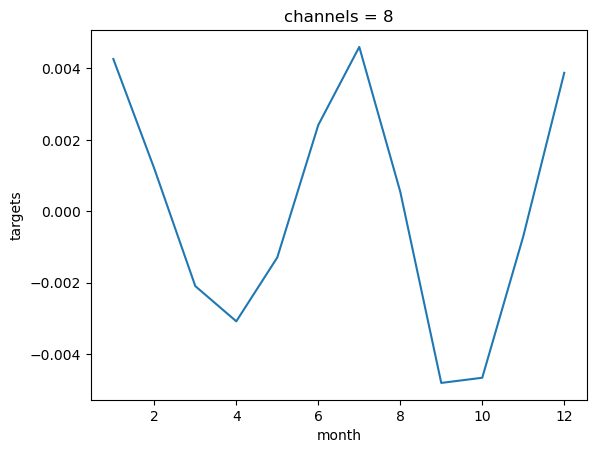

In [13]:
seasonality.isel(channels=8).mean(("lat","lon")).plot()
plt.show()

In [14]:
sst_tendency_deseasoned = da.isel(channels=8).mean(("lat", "lon"))

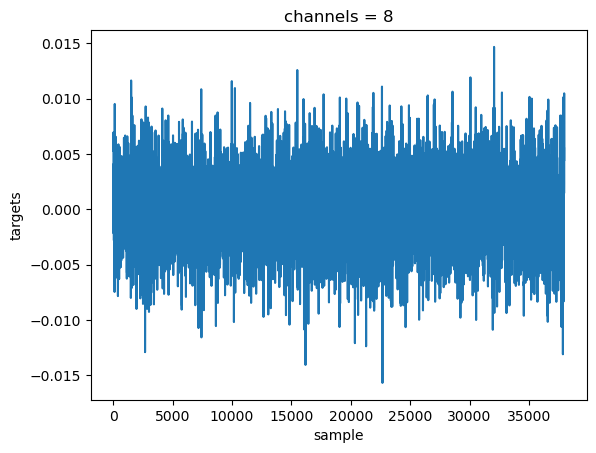

In [15]:
sst_tendency_deseasoned.plot()
plt.show()

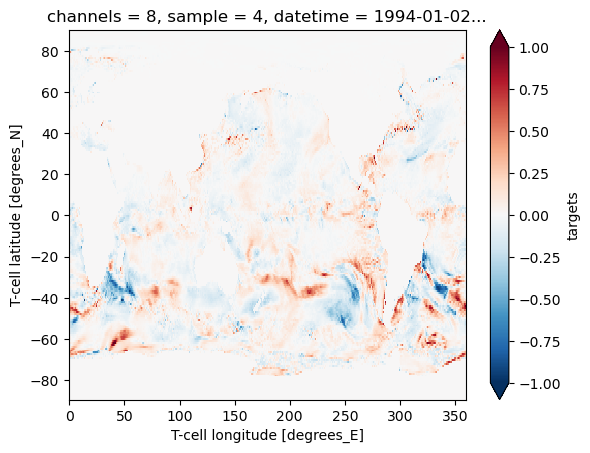

In [18]:
# plot any one snapshot
da.isel(channels=8, sample=0).plot(vmin=-1, vmax=1, cmap="RdBu_r")
plt.show()

## Compute Covariance

In [12]:
# Define the DataArray to work on depending on whether the seasonality 
# is removed or not
norm = True
spatial_avg = False
da.load()

<xarray.DataArray 'targets' (sample: 9495, lat: 192, lon: 384, channels: 29)> Size: 81GB
array([[[[-6.7239082e-01,  3.1557816e+01,  3.1564848e+01, ...,
          -4.2895079e-03,  4.8826472e-03,  5.7977149e-03],
         [-6.7248613e-01,  3.1558796e+01,  3.1565294e+01, ...,
          -4.1888151e-03,  4.7467044e-03,  5.5928808e-03],
         [-6.7256206e-01,  3.1559572e+01,  3.1565573e+01, ...,
          -4.0946119e-03,  4.6209563e-03,  5.4009273e-03],
         ...,
         [-6.7194563e-01,  3.1552742e+01,  3.1560997e+01, ...,
          -4.4338829e-03,  5.3033261e-03,  6.4155557e-03],
         [-6.7213470e-01,  3.1555164e+01,  3.1563393e+01, ...,
          -4.5138500e-03,  5.1909396e-03,  6.2542255e-03],
         [-6.7227435e-01,  3.1556612e+01,  3.1564220e+01, ...,
          -4.3977122e-03,  5.0302465e-03,  6.0174912e-03]],

        [[-7.2953641e-01,  3.2545525e+01,  3.2548637e+01, ...,
           1.3382020e-02,  5.6073461e-03,  4.1074185e-03],
         [-7.3013866e-01,  3.2561760e+01,  3.2563919e+01, ...,
           1.3553743e-02,  6.2816399e-03,  4.6669040e-03],
         [-7.3083401e-01,  3.2581501e+01,  3.2583672e+01, ...,
           1.3560444e-02,  6.5699462e-03,  4.8664622e-03],
...
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00]],

        [[ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         ...,
         [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
         [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
           0.0000000e+00,  0.0000000e+00,  0.0000000e+00]]]],
      shape=(9495, 192, 384, 29), dtype=float32)
Coordinates:
  * channels  (channels) int64 232B 0 1 2 3 4 5 6 7 ... 21 22 23 24 25 26 27 28
  * lat       (lat) float64 2kB 89.82 88.89 87.95 87.01 ... -87.25 -88.18 -89.12
  * lon       (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
  * sample    (sample) int64 76kB 0 4 8 12 16 ... 37960 37964 37968 37972 37976
    datetime  (sample) datetime64[ns] 76kB 1994-01-01T18:00:00 ... 2019-12-30...

In [13]:
# Eagerly compute the covariance
out = cross_covariance_flexible(da, dim="channels", spatial_avg=spatial_avg, norm=norm).compute()

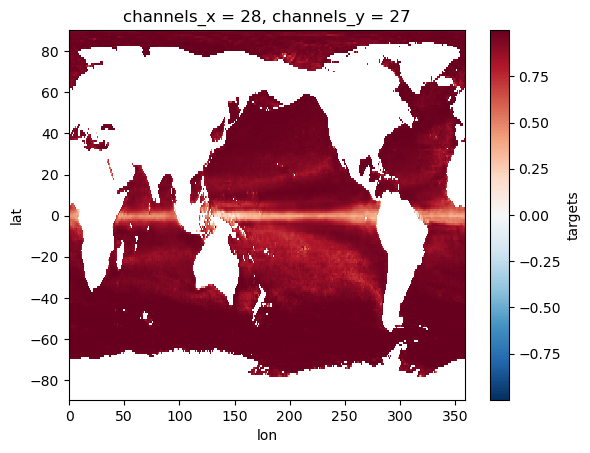

In [23]:
out.isel(channels_x=-1, channels_y=-2).plot()
plt.show()

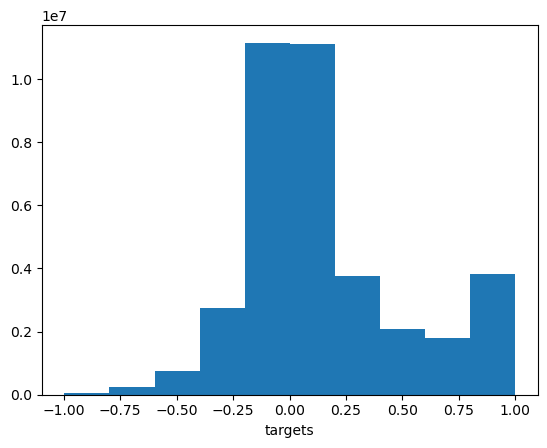

In [14]:
# Plot 
out.plot()
plt.show()

In [15]:
np.trace(out.values)

np.float32(29.0)

In [16]:
# Convert to dataset and write to disk
name = "correlation" if norm else "covariance"
ds_out = out.to_dataset(name="targets")

In [18]:
# Define the file name
seasonality_suffix = "rm_seasonality" if remove_seasonality else "seasonality_intact"
output_file = f"./tendency_{name}_ocn_only_{target_lead_time}h_{seasonality_suffix}.nc"

In [21]:
# Save to file
ds_out.to_netcdf(output_file)
print(f"Saved {name} matrix to {output_file}")

Saved correlation matrix to ./Full_temporal_correlation_ocn_only_seasonality_intact.nc


## Open saved covariance/correlation

In [11]:
file_loc = "/global/homes/n/nagarwal/graph-ufs/prototypes/ocn_only/tendency_correlations"
#cov_file_name = "tendency_covariance_ocn_only_6h.nc"
corr_file_name = "tendency_correlation_ocn_only_24h_rm_seasonality_space_dependent.nc"

In [12]:
# open file
f = xr.open_dataset(os.path.join(file_loc, corr_file_name))
f

<xarray.Dataset> Size: 248MB
Dimensions:     (channels_x: 29, lat: 192, lon: 384, channels_y: 29)
Coordinates:
  * channels_x  (channels_x) int64 232B 0 1 2 3 4 5 6 7 ... 22 23 24 25 26 27 28
  * lat         (lat) float64 2kB 89.82 88.89 87.95 ... -87.25 -88.18 -89.12
  * lon         (lon) float64 3kB 0.0 0.9375 1.875 2.812 ... 357.2 358.1 359.1
  * channels_y  (channels_y) int64 232B 0 1 2 3 4 5 6 7 ... 22 23 24 25 26 27 28
Data variables:
    targets     (lat, lon, channels_x, channels_y) float32 248MB ...

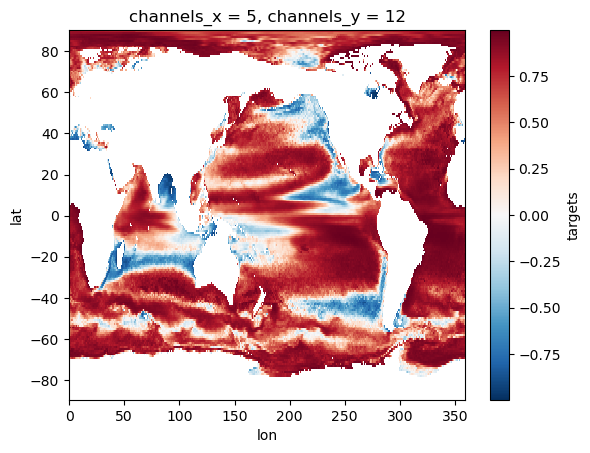

In [13]:
# define what variable and level you want to visualize
#channels_x_idx = search_meta_dict(meta_targets, "varname", "temp", "z_l", "5")
#channels_y_idx = search_meta_dict(meta_targets, "varname", "so", "z_l", "5")

# plot
f.targets.isel(channels_x=5, channels_y=12).plot()
plt.show()

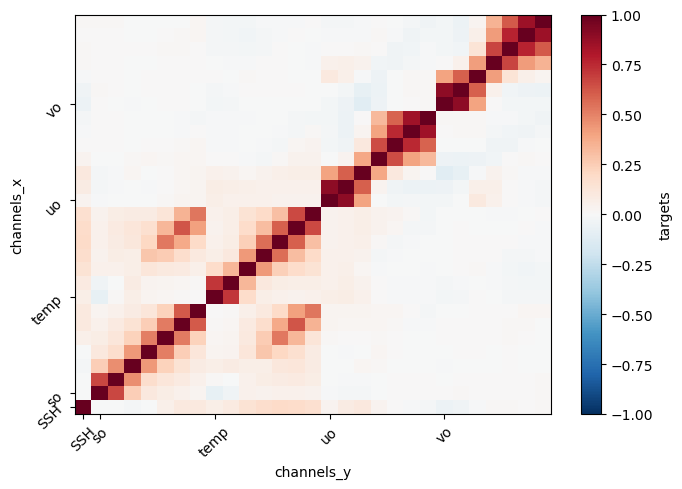

In [27]:
# plot
fig, ax = plt.subplots(1, 1, figsize=(7,5))
f.targets.mean(["lat","lon"]).plot(ax=ax, cmap="RdBu_r",)
ticks = (0, 1, 8, 15, 22,)
#ticklabels = []
#for idx, i in enumerate(ticks):
#    var_name = meta_targets[i]['varname']
#    label = f"{var_name}"
#    if "z_l" in meta_targets[i]:
#        label += f"_z{meta_targets[i]['z_l']}"
#    ticklabels.append(label)
ticklabels = [meta_targets[i]["varname"] for i in ticks]   
ax.set_xticks(ticks,); ax.set_yticks(ticks,)
ax.set_xticklabels(ticklabels,); ax.set_yticklabels(ticklabels,)
ax.tick_params(labelrotation=45)
plt.tight_layout()
#plt.savefig(f"./figures/tendency_correlation_24h.png", dpi=300)
plt.show()

## Compare 6h and 24h correlation matrices

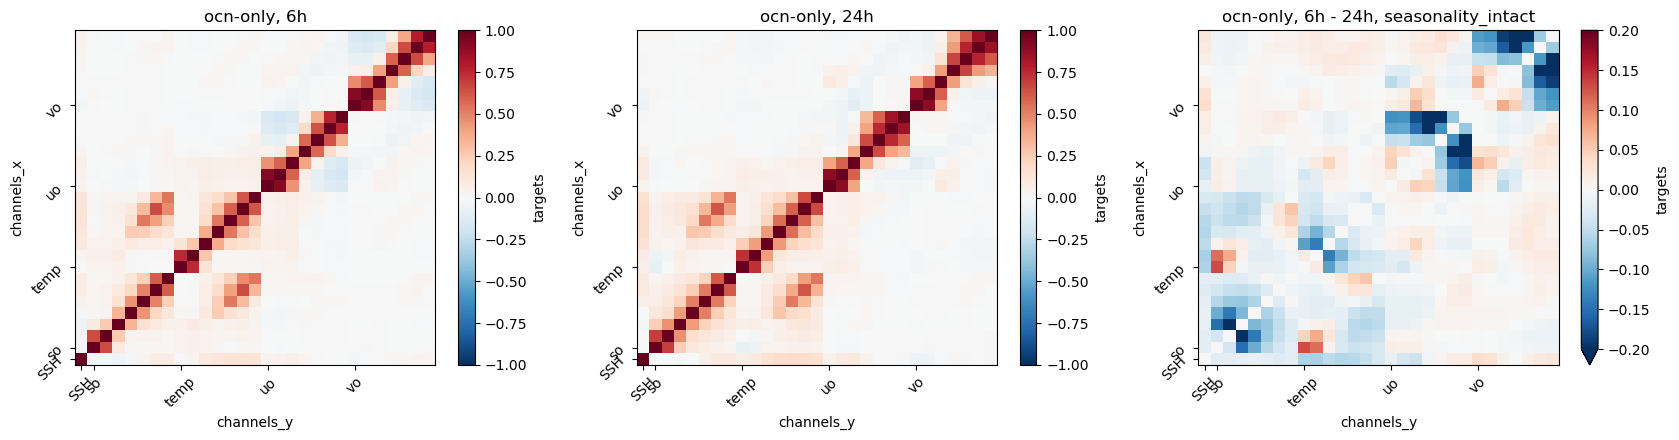

In [21]:
time_steps = ["6h", "24h"]
file_loc = "/global/homes/n/nagarwal/graph-ufs/prototypes/ocn_only"
seasonality_suffix = "seasonality_intact"

corr = {}

fig, ax = plt.subplots(1, 3, figsize=(17,4.5))

for i, ts in enumerate(time_steps):
    fname = f"tendency_correlation_ocn_only_{ts}_{seasonality_suffix}.nc"
    f = xr.open_dataset(os.path.join(file_loc, fname))
    corr[ts] = f.targets
    _ = plot_correlation(ax[i], corr[ts], meta=meta_targets,
                         title=f"ocn-only, {ts}")

# plot the difference in the third panel
diff = corr["6h"] - corr["24h"]
_ = plot_correlation(ax[2], diff, meta=meta_targets,
                     title=f"ocn-only, 6h - 24h, {seasonality_suffix}",
                     vmin=-0.2, vmax=0.2,
                    )

plt.tight_layout()
plt.savefig(f"./figures/compare_correlations_6h_24h_{seasonality_suffix}.png", dpi=300)
plt.show()

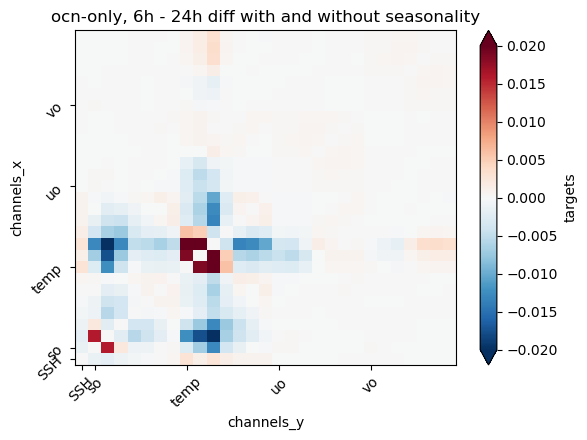

In [16]:
file_loc = "/global/homes/n/nagarwal/graph-ufs/prototypes/ocn_only"
seasonality_suffix = ["seasonality_intact", "rm_seasonality"]

diff6h24h = {}

fig, ax = plt.subplots(1, 1, figsize=(6,4.5))

for i, ss in enumerate(seasonality_suffix):
    fname = f"tendency_correlation_ocn_only_6h_{ss}.nc"
    f6h = xr.open_dataset(os.path.join(file_loc, fname))

    fname = f"tendency_correlation_ocn_only_24h_{ss}.nc"
    f24h = xr.open_dataset(os.path.join(file_loc, fname))
    
    # difference
    diff6h24h[ss] = f24h.targets - f6h.targets
    
diff = diff6h24h["seasonality_intact"] - diff6h24h["rm_seasonality"]
_ = plot_correlation(ax, diff, meta=meta_targets,
                     title=f"ocn-only, 6h - 24h diff with and without seasonality",
                     vmin=-0.02, vmax=0.02,)
plt.tight_layout()
plt.show()

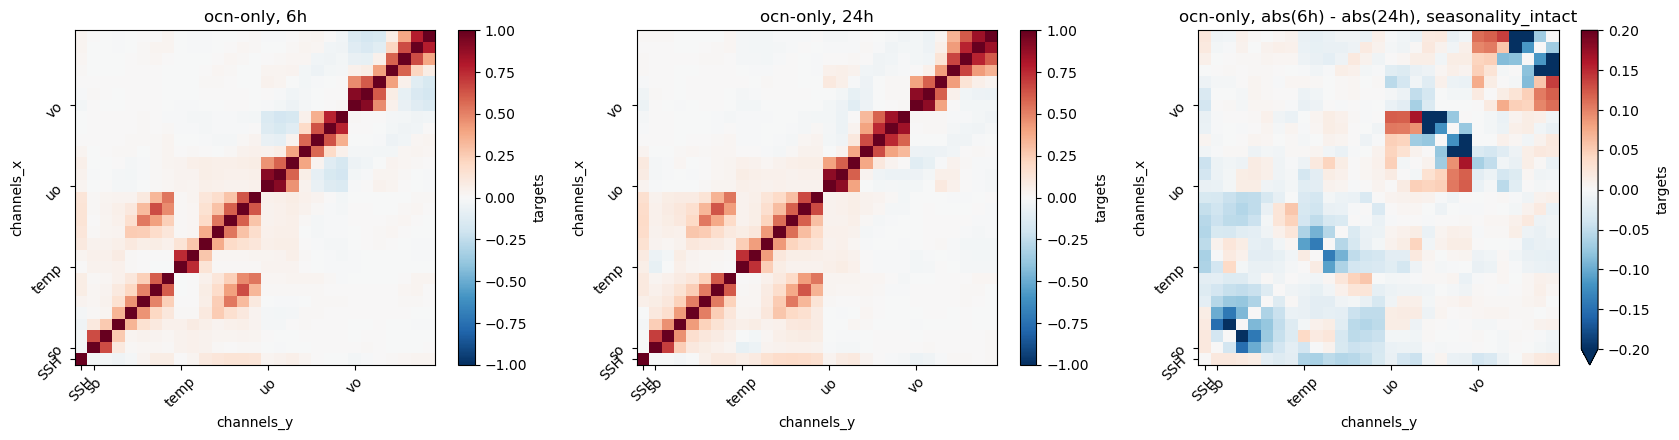

In [22]:
time_steps = ["6h", "24h"]
file_loc = "/global/homes/n/nagarwal/graph-ufs/prototypes/ocn_only"
seasonality_suffix = "seasonality_intact"

corr = {}

fig, ax = plt.subplots(1, 3, figsize=(17,4.5))

for i, ts in enumerate(time_steps):
    fname = f"tendency_correlation_ocn_only_{ts}_{seasonality_suffix}.nc"
    f = xr.open_dataset(os.path.join(file_loc, fname))
    corr[ts] = f.targets
    _ = plot_correlation(ax[i], corr[ts], meta=meta_targets,
                         title=f"ocn-only, {ts}")

# plot the difference in the third panel
diff = abs(corr["6h"]) - abs(corr["24h"])
_ = plot_correlation(ax[2], diff, meta=meta_targets,
                     title=f"ocn-only, abs(6h) - abs(24h), {seasonality_suffix}",
                     vmin=-0.2, vmax=0.2,
                    )

plt.tight_layout()
plt.savefig(f"./figures/compare_correlations_6h_24h_{seasonality_suffix}_diff_absolute_values.png", dpi=300)
plt.show()

## Compare seasonality removed vs seasonality intact covariances

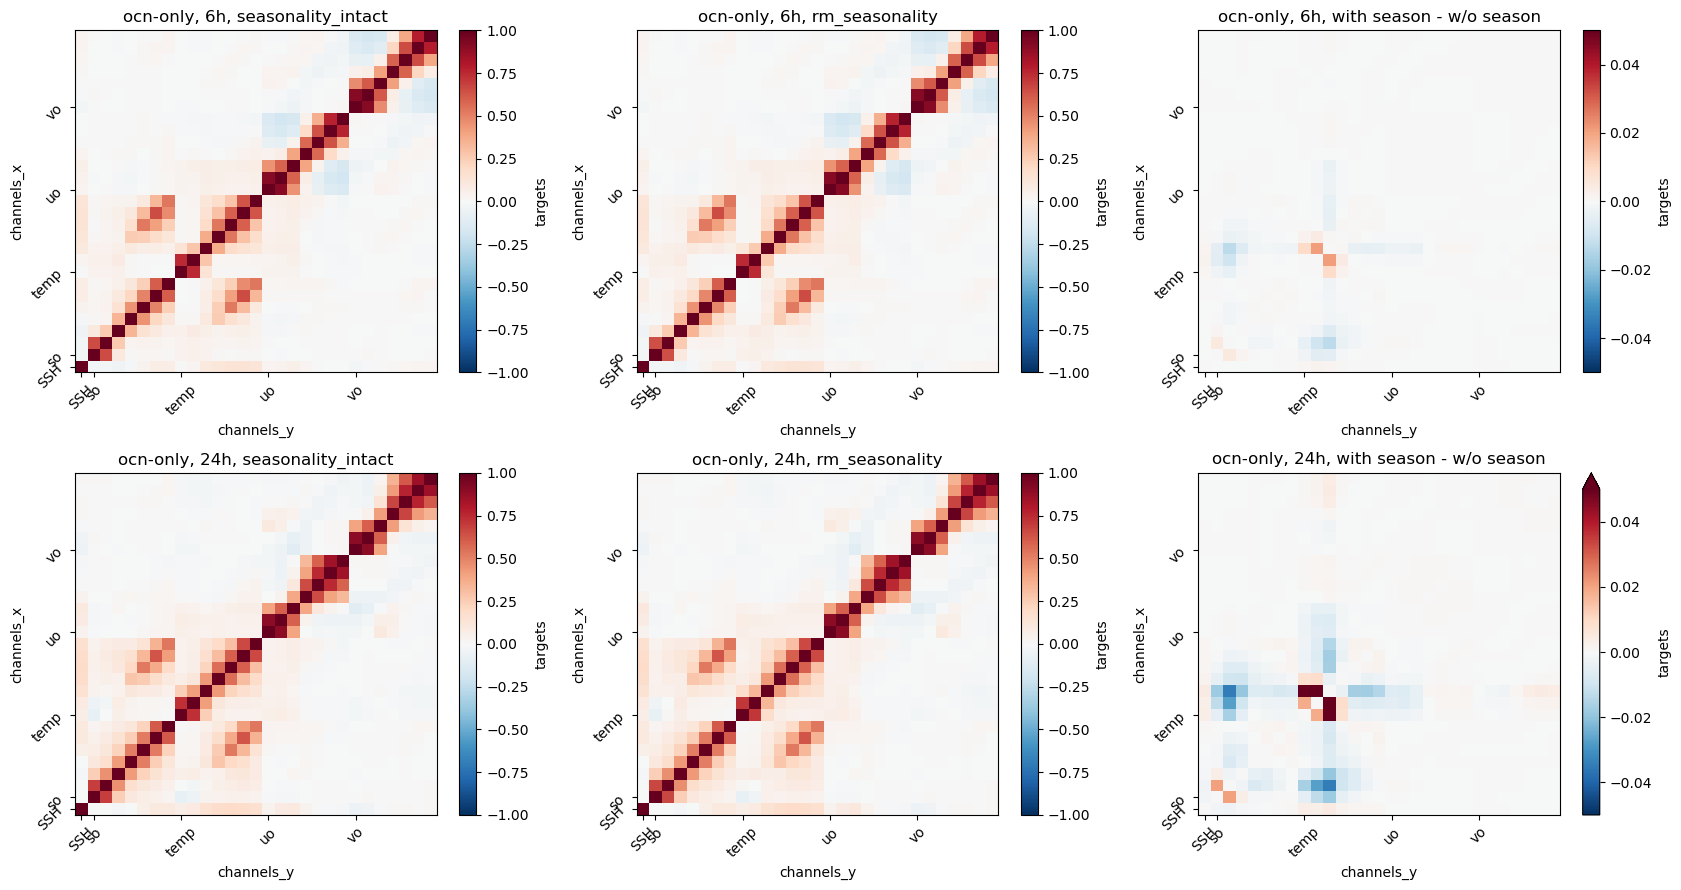

In [16]:
time_steps = ["6h", "24h"]
file_loc = "/global/homes/n/nagarwal/graph-ufs/prototypes/ocn_only"

files = {}
corr = {}

fig, ax = plt.subplots(len(time_steps), 3, figsize=(17,9))

for i, ts in enumerate(time_steps):

    files["seasonality_intact"] = f"tendency_correlation_ocn_only_{ts}_seasonality_intact.nc"
    files["rm_seasonality"] = f"tendency_correlation_ocn_only_{ts}_rm_seasonality.nc"
    
    for j, key in enumerate(list(files.keys())):
        f = xr.open_dataset(os.path.join(file_loc, files[key]))
        corr[key] = f.targets
        _ = plot_correlation(ax[i][j], corr[key], meta=meta_targets,
                             title=f"ocn-only, {ts}, {key}")

    # plot the difference in the third panel
    diff = corr["seasonality_intact"] - corr["rm_seasonality"]
    _ = plot_correlation(ax[i][2], diff, meta=meta_targets,
                         title=f"ocn-only, {ts}, with season - w/o season",
                         vmin=-0.05, vmax=0.05,
                         )

    files = {}
    
plt.tight_layout()
plt.savefig("./figures/compare_correlations_6h_24h_with_and_without_seasonality.png", dpi=300)
plt.show()

In [33]:
corr["seasonality_intact"].isel(channels_x=slice(8,11), channels_y=1).values

array([-0.08308747, -0.05688471,  0.03210913], dtype=float32)

In [34]:
corr["rm_seasonality"].isel(channels_x=slice(8,11), channels_y=1).values

array([-0.07822192, -0.04404007,  0.05039969])

# Compare any two given correlation matrices

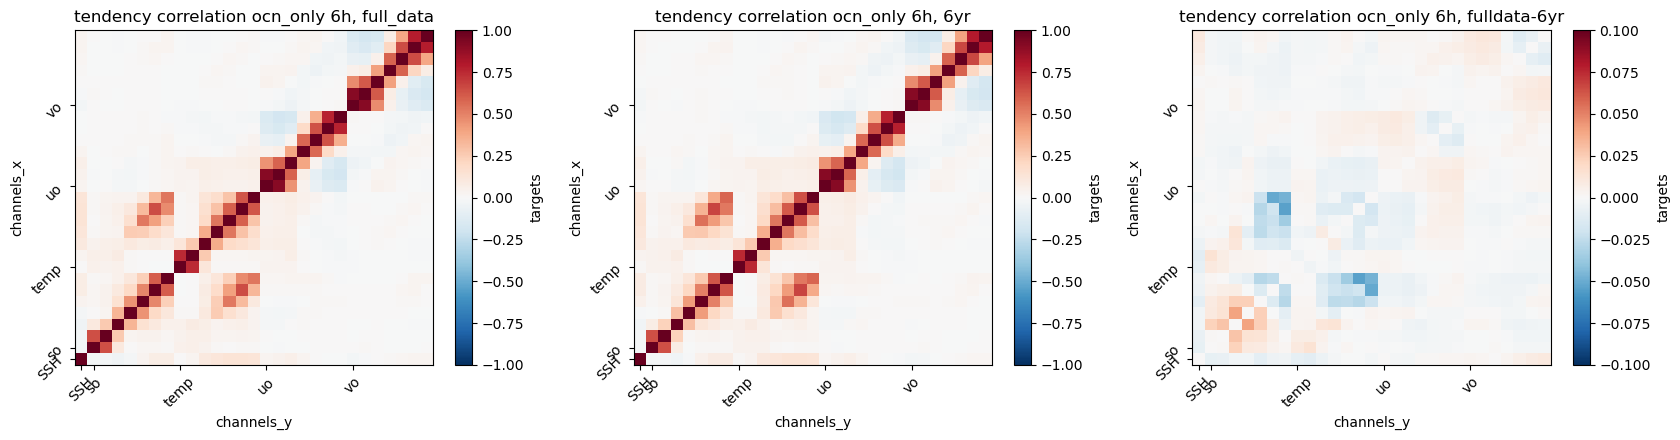

In [38]:
file_loc = "/global/homes/n/nagarwal/graph-ufs/prototypes/ocn_only"
corr = {}
files = {}

files["full_data"] = "tendency_correlation_ocn_only_6h_rm_seasonality.nc"
files["6yr"] = "tendency_correlation_ocn_only_6h_rm_seasonality_6yr_data.nc"

fig, ax = plt.subplots(1, len(files)+1, figsize=(17,4.5))

for i, key in enumerate(list(files.keys())):
    f = xr.open_dataset(os.path.join(file_loc, files[key]))
    corr[key] = f.targets
    _ = plot_correlation(ax[i], corr[key], meta=meta_targets,
                         title=f"tendency correlation ocn_only 6h, {key}")

# plot the difference in the third panel
diff = corr["full_data"] - corr["6yr"]
_ = plot_correlation(ax[2], diff, meta=meta_targets,
                     title="tendency correlation ocn_only 6h, fulldata-6yr",
                     vmin=-0.1, vmax=0.1,
                    )

plt.tight_layout()
plt.show()